In [ ]:
!pip -q install "jax[cpu]" dm-haiku optax rlax gymnasium matplotlib numpy

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import random
import time
from dataclasses import dataclass
from collections import deque

import gymnasium as gym
import haiku as hk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import rlax

seed = 42
random.seed(seed)
np.random.seed(seed)

env = gym.make("CartPole-v1")
eval_env = gym.make("CartPole-v1")

obs_dim = env.observation_space.shape[0]
num_actions = env.action_space.n

def q_network(x):
    mlp = hk.Sequential([
        hk.Linear(128), jax.nn.relu,
        hk.Linear(128), jax.nn.relu,
        hk.Linear(num_actions),
    ])
    return mlp(x)

q_net = hk.without_apply_rng(hk.transform(q_network))

dummy_obs = jnp.zeros((1, obs_dim), dtype=jnp.float32)
rng = jax.random.PRNGKey(seed)
params = q_net.init(rng, dummy_obs)
target_params = params

optimizer = optax.chain(
    optax.clip_by_global_norm(10.0),
    optax.adam(3e-4),
)
opt_state = optimizer.init(params)

In [ ]:
@dataclass
class Transition:
    obs: np.ndarray
    action: int
    reward: float
    discount: float
    next_obs: np.ndarray
    done: float

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs = np.stack([t.obs for t in batch]).astype(np.float32)
        action = np.array([t.action for t in batch], dtype=np.int32)
        reward = np.array([t.reward for t in batch], dtype=np.float32)
        discount = np.array([t.discount for t in batch], dtype=np.float32)
        next_obs = np.stack([t.next_obs for t in batch]).astype(np.float32)
        done = np.array([t.done for t in batch], dtype=np.float32)
        return {
            "obs": obs,
            "action": action,
            "reward": reward,
            "discount": discount,
            "next_obs": next_obs,
            "done": done,
        }

    def __len__(self):
        return len(self.buffer)

replay = ReplayBuffer(capacity=50000)

def epsilon_by_frame(frame_idx, eps_start=1.0, eps_end=0.05, decay_frames=20000):
    mix = min(frame_idx / decay_frames, 1.0)
    return eps_start + mix * (eps_end - eps_start)

def select_action(params, obs, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    q_values = q_net.apply(params, obs[None, :])
    return int(jnp.argmax(q_values[0]))

In [ ]:
@jax.jit
def soft_update(target_params, online_params, tau):
    return jax.tree_util.tree_map(lambda t, s: (1.0 - tau) * t + tau * s, target_params, online_params)

def batch_td_errors(params, target_params, batch):
    q_tm1 = q_net.apply(params, batch["obs"])
    q_t = q_net.apply(target_params, batch["next_obs"])
    td_errors = jax.vmap(
        lambda q1, a, r, d, q2: rlax.q_learning(q1, a, r, d, q2)
    )(q_tm1, batch["action"], batch["reward"], batch["discount"], q_t)
    return td_errors

@jax.jit
def train_step(params, target_params, opt_state, batch):
    def loss_fn(p):
        td_errors = batch_td_errors(p, target_params, batch)
        loss = jnp.mean(rlax.huber_loss(td_errors, delta=1.0))
        metrics = {
            "loss": loss,
            "td_abs_mean": jnp.mean(jnp.abs(td_errors)),
            "q_mean": jnp.mean(q_net.apply(p, batch["obs"])),
        }
        return loss, metrics

    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, metrics

In [ ]:
def evaluate_agent(params, episodes=5):
    returns = []
    for ep in range(episodes):
        obs, _ = eval_env.reset(seed=seed + 1000 + ep)
        done = False
        truncated = False
        total_reward = 0.0
        while not (done or truncated):
            q_values = q_net.apply(params, obs[None, :])
            action = int(jnp.argmax(q_values[0]))
            next_obs, reward, done, truncated, _ = eval_env.step(action)
            total_reward += reward
            obs = next_obs
        returns.append(total_reward)
    return float(np.mean(returns))

num_frames = 40000
batch_size = 128
warmup_steps = 1000
train_every = 4
eval_every = 2000
gamma = 0.99
tau = 0.01
max_grad_updates_per_step = 1

obs, _ = env.reset(seed=seed)
episode_return = 0.0
episode_returns = []
eval_returns = []
losses = []
td_means = []
q_means = []
eval_steps = []

start_time = time.time()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.2/116.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.7/312.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 65.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.
step=  2000 | epsilon=0.905 | recent_train_return=  21.00 | eval_return=   9.20 | recent_loss=0.10781 | buffer=2000
step=  4000 | epsilon=0.810 | recent_train_return=  20.00 

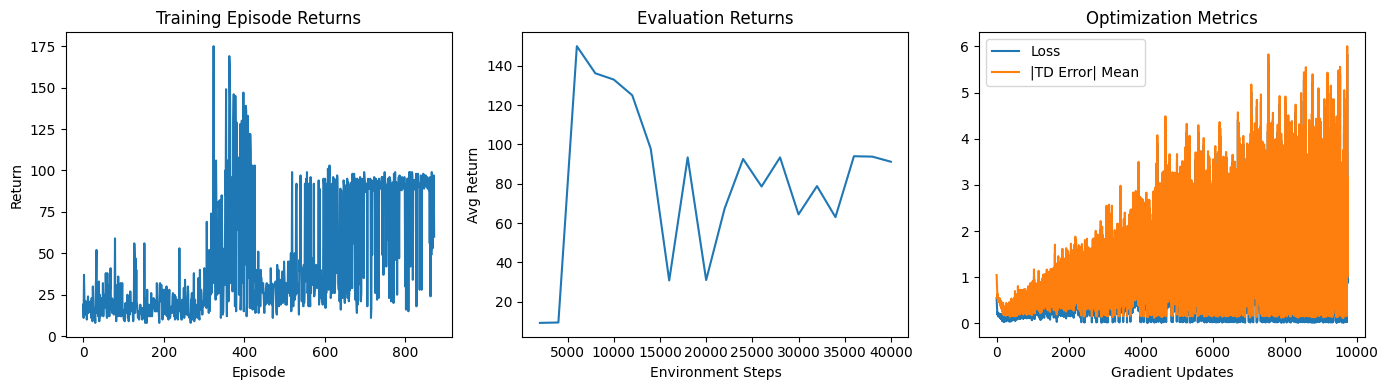

Demo episode return: 95.00


In [1]:
for frame_idx in range(1, num_frames + 1):
    epsilon = epsilon_by_frame(frame_idx)
    action = select_action(params, obs.astype(np.float32), epsilon)
    next_obs, reward, done, truncated, _ = env.step(action)
    terminal = done or truncated
    discount = 0.0 if terminal else gamma

    replay.add(
        obs.astype(np.float32),
        action,
        float(reward),
        float(discount),
        next_obs.astype(np.float32),
        float(terminal),
    )

    obs = next_obs
    episode_return += reward

    if terminal:
        episode_returns.append(episode_return)
        obs, _ = env.reset()
        episode_return = 0.0

    if len(replay) >= warmup_steps and frame_idx % train_every == 0:
        for _ in range(max_grad_updates_per_step):
            batch_np = replay.sample(batch_size)
            batch = {k: jnp.asarray(v) for k, v in batch_np.items()}
            params, opt_state, metrics = train_step(params, target_params, opt_state, batch)
            target_params = soft_update(target_params, params, tau)
            losses.append(float(metrics["loss"]))
            td_means.append(float(metrics["td_abs_mean"]))
            q_means.append(float(metrics["q_mean"]))

    if frame_idx % eval_every == 0:
        avg_eval_return = evaluate_agent(params, episodes=5)
        eval_returns.append(avg_eval_return)
        eval_steps.append(frame_idx)
        recent_train = np.mean(episode_returns[-10:]) if episode_returns else 0.0
        recent_loss = np.mean(losses[-100:]) if losses else 0.0
        print(
            f"step={frame_idx:6d} | epsilon={epsilon:.3f} | "
            f"recent_train_return={recent_train:7.2f} | "
            f"eval_return={avg_eval_return:7.2f} | "
            f"recent_loss={recent_loss:.5f} | buffer={len(replay)}"
        )

elapsed = time.time() - start_time
final_eval = evaluate_agent(params, episodes=10)

print("\nTraining complete")
print(f"Elapsed time: {elapsed:.1f} seconds")
print(f"Final 10-episode evaluation return: {final_eval:.2f}")

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.plot(episode_returns)
plt.title("Training Episode Returns")
plt.xlabel("Episode")
plt.ylabel("Return")

plt.subplot(1, 3, 2)
plt.plot(eval_steps, eval_returns)
plt.title("Evaluation Returns")
plt.xlabel("Environment Steps")
plt.ylabel("Avg Return")

plt.subplot(1, 3, 3)
plt.plot(losses, label="Loss")
plt.plot(td_means, label="|TD Error| Mean")
plt.title("Optimization Metrics")
plt.xlabel("Gradient Updates")
plt.legend()

plt.tight_layout()
plt.show()

obs, _ = eval_env.reset(seed=999)
frames = []
done = False
truncated = False
total_reward = 0.0

render_env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = render_env.reset(seed=999)

while not (done or truncated):
    frame = render_env.render()
    frames.append(frame)
    q_values = q_net.apply(params, obs[None, :])
    action = int(jnp.argmax(q_values[0]))
    obs, reward, done, truncated, _ = render_env.step(action)
    total_reward += reward

render_env.close()

print(f"Demo episode return: {total_reward:.2f}")

try:
    import matplotlib.animation as animation
    from IPython.display import HTML, display

    fig = plt.figure(figsize=(6, 4))
    patch = plt.imshow(frames[0])
    plt.axis("off")

    def animate(i):
        patch.set_data(frames[i])
        return (patch,)

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=30, blit=True)
    display(HTML(anim.to_jshtml()))
    plt.close(fig)
except Exception as e:
    print("Animation display skipped:", e)